# Stage 21b — Attention Analysis (λ_ent=0)

Analyses M4-attn without entropy regularisation (`proto_seg_ct_l1234_attn_noent.pth`).
Compares M4 / M4-attn (λ=0.02, uniform) / M4-attn-noent (λ=0, learned) / M2.

## 1. Imports & Config

In [1]:
import sys, os
_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault('PYTORCH_MPS_HIGH_WATERMARK_RATIO', '0.0')
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.data.mmwhs_dataset import make_dataloaders, LABEL_NAMES, NUM_CLASSES, MMWHSPatientDataset, MMWHSSliceDataset
from src.models.proto_seg_net import ProtoSegNet
from src.metrics.proto_quality import (
    compute_purity, compute_utilization, compute_compactness,
    compute_level_dominance, compute_per_level_ap
)
from src.metrics.dice import dice_per_class, mean_foreground_dice

MODALITY     = 'ct'
DATA_DIR     = 'data/pack/processed_data'
SUFFIX_NOENT = '_l1234_attn_noent'
OUT          = f'results/v5/proto_quality/m4_attn_noent'
DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available()          else
    torch.device('cpu')
)
FG_NAMES     = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
LEVEL_COLORS = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
print(f'Device: {DEVICE}')

Device: mps


## 2. Load Models

In [2]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=16)

def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    levels = ckpt.get('proto_levels') or [1, 2, 3, 4]
    m = ProtoSegNet(n_classes=NUM_CLASSES, proto_levels=levels,
                    use_level_attention=ckpt.get('use_level_attention', False)).to(DEVICE)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    print(f"{path.split('/')[-1]:<48}  levels={levels}  attn={ckpt.get('use_level_attention',False)}  best_val={ckpt.get('best_val_dice',0):.4f}")
    return m

m4        = load_model('checkpoints/proto_seg_ct_l2.pth')
m4_attn   = load_model('checkpoints/proto_seg_ct_l1234_attn.pth')      # λ=0.02 uniform
m4_noent  = load_model('checkpoints/proto_seg_ct_l1234_attn_noent.pth') # λ=0   learned
m2        = load_model('checkpoints/proto_seg_ct_l3l4.pth')

proto_seg_ct_l2.pth                               levels=[1, 2, 3, 4]  attn=False  best_val=0.8173
proto_seg_ct_l1234_attn.pth                       levels=[1, 2, 3, 4]  attn=True  best_val=0.7711
proto_seg_ct_l1234_attn_noent.pth                 levels=[1, 2, 3, 4]  attn=True  best_val=0.7949
proto_seg_ct_l3l4.pth                             levels=[3, 4]  attn=False  best_val=0.8380


## 3. 3D Dice Evaluation

In [3]:
@torch.no_grad()
def eval_3d(model, label):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, 'test')
    all_means, per_class = [], {n: [] for n in FG_NAMES}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s['image'].to(DEVICE)
        logits_all = [model(imgs[si:si+1])[0].cpu() for si in range(imgs.shape[0])]
        d = dice_per_class(torch.cat(logits_all), s['label'])
        mfg = mean_foreground_dice(d)
        all_means.append(mfg)
        for n in FG_NAMES: per_class[n].append(d.get(n, float('nan')))
    mean_fg = float(np.mean(all_means))
    pc = {n: float(np.mean(v)) for n, v in per_class.items()}
    print(f"[{label:<20}]  3D Dice = {mean_fg:.4f}")
    return mean_fg, pc

dice_m4,       pc_m4       = eval_3d(m4,       'M4 (max)')
dice_m4_attn,  pc_m4_attn  = eval_3d(m4_attn,  'M4-attn λ=0.02')
dice_m4_noent, pc_m4_noent = eval_3d(m4_noent, 'M4-attn λ=0')
dice_m2,       pc_m2       = eval_3d(m2,       'M2 (max)')

print(f"\nM4-attn (λ=0) vs M4      : {dice_m4_noent - dice_m4:+.4f}")
print(f"M4-attn (λ=0) vs M4-attn : {dice_m4_noent - dice_m4_attn:+.4f}")
print(f"M4-attn (λ=0) vs M2      : {dice_m4_noent - dice_m2:+.4f}")

[M4 (max)            ]  3D Dice = 0.8407


[M4-attn λ=0.02      ]  3D Dice = 0.7861


[M4-attn λ=0         ]  3D Dice = 0.8416


[M2 (max)            ]  3D Dice = 0.8722

M4-attn (λ=0) vs M4      : +0.0009
M4-attn (λ=0) vs M4-attn : +0.0555
M4-attn (λ=0) vs M2      : -0.0306


## 4. Proto Quality Metrics — M4-attn (λ=0)

In [4]:
import pathlib
pathlib.Path(OUT).mkdir(parents=True, exist_ok=True)

print("Computing purity…")
purity = compute_purity(m4_noent, loaders['train'])
purity.to_csv(f'{OUT}/purity_summary.csv', index=False)

print("Computing compactness…")
comp = compute_compactness(m4_noent, loaders['test'])
comp.to_csv(f'{OUT}/compactness.csv', index=False)

print("Computing level dominance…")
dom = compute_level_dominance(m4_noent, loaders['test'])
dom.to_csv(f'{OUT}/level_dominance.csv', index=False)

print("Computing per-level AP…")
ap = compute_per_level_ap(m4_noent, loaders['test'])
ap.to_csv(f'{OUT}/per_level_ap.csv', index=False)

print("Done.")
print(f"  Purity L4    : {purity[purity['level']==4]['purity'].mean():.3f}")
print(f"  Dominance    : {dom.iloc[0].to_dict()}")
print(f"  AP L4 (mean) : {ap[ap['level']==4]['ap'].mean():.3f}")

Computing purity…


Computing compactness…


Computing level dominance…


Computing per-level AP…


Done.
  Purity L4    : 0.537
  Dominance    : {'frac_l1': 0.2810823109524309, 'frac_l2': 0.45018872347745026, 'frac_l3': 0.14325184467410254, 'frac_l4': 0.12547712089601626}
  AP L4 (mean) : 0.085


## 5. Four-Way Comparison Table

In [5]:
def pur_l4(df):
    if 'mean' in df.columns: return df[df['level']==4]['mean'].values[0]
    return df[df['level']==4]['purity'].mean()

def load_dom_l4(path):
    df = pd.read_csv(path)
    return df.iloc[0].get('frac_l4', 0)

def load_ap_l4(path):
    df = pd.read_csv(path)
    return df[df['level']==4]['ap'].mean()

def load_comp_l4(path):
    df = pd.read_csv(path)
    return df[df['level']==4]['compactness'].mean()

# Pre-computed
m4_pur   = pur_l4(pd.read_csv('results/v4/proto_quality/v1/purity_summary.csv'))
m4_dom   = load_dom_l4('results/v4/proto_quality/v1/level_dominance.csv')
m4_ap    = load_ap_l4('results/v4/proto_quality/v1/per_level_ap.csv')
m4_comp  = load_comp_l4('results/v4/proto_quality/v1/compactness.csv')

attn_pur  = pur_l4(pd.read_csv('results/v5/proto_quality/m4_attn/purity_summary.csv'))
attn_dom  = load_dom_l4('results/v5/proto_quality/m4_attn/level_dominance.csv')
attn_ap   = load_ap_l4('results/v5/proto_quality/m4_attn/per_level_ap.csv')
attn_comp = load_comp_l4('results/v5/proto_quality/m4_attn/compactness.csv')

noent_pur  = pur_l4(purity)
noent_dom  = dom.iloc[0].get('frac_l4', 0)
noent_ap   = ap[ap['level']==4]['ap'].mean()
noent_comp = comp[comp['level']==4]['compactness'].mean()

m2_pur  = pur_l4(pd.read_csv('results/v4/proto_quality/m2_l3l4/purity_summary.csv'))
m2_dom  = load_dom_l4('results/v4/proto_quality/m2_l3l4/level_dominance.csv')
m2_ap   = load_ap_l4('results/v4/proto_quality/m2_l3l4/per_level_ap.csv')
m2_comp = load_comp_l4('results/v4/proto_quality/m2_l3l4/compactness.csv')

rows = {
    'Model':          ['M4 (max)',   'M4-attn λ=0.02', 'M4-attn λ=0',  'M2 (max)'],
    'Aggregation':    ['max',        'uniform avg',    'learned attn', 'max'],
    '3D Dice':        [f'{dice_m4:.4f}', f'{dice_m4_attn:.4f}', f'{dice_m4_noent:.4f}', f'{dice_m2:.4f}'],
    'Purity L4':      [f'{m4_pur:.3f}', f'{attn_pur:.3f}', f'{noent_pur:.3f}', f'{m2_pur:.3f}'],
    'Compact. L4':    [f'{m4_comp:.3f}', f'{attn_comp:.3f}', f'{noent_comp:.3f}', f'{m2_comp:.3f}'],
    'AP L4':          [f'{m4_ap:.3f}', f'{attn_ap:.3f}', f'{noent_ap:.3f}', f'{m2_ap:.3f}'],
    'Dom. L4':        [f'{m4_dom*100:.1f}%', f'{attn_dom*100:.1f}%', f'{noent_dom*100:.1f}%', f'{m2_dom*100:.1f}%'],
}
df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
df_cmp.to_csv('results/v5/proto_quality/comparison_table_full.csv', index=False)

         Model  Aggregation 3D Dice Purity L4 Compact. L4 AP L4 Dom. L4
      M4 (max)          max  0.8407     0.824       0.573 0.189    4.3%
M4-attn λ=0.02  uniform avg  0.7861     0.526       0.575 0.187    9.7%
   M4-attn λ=0 learned attn  0.8416     0.537       0.494 0.085   12.5%
      M2 (max)          max  0.8722     0.804       0.361 0.236   49.1%


## 6. Attention Weight Evolution Comparison

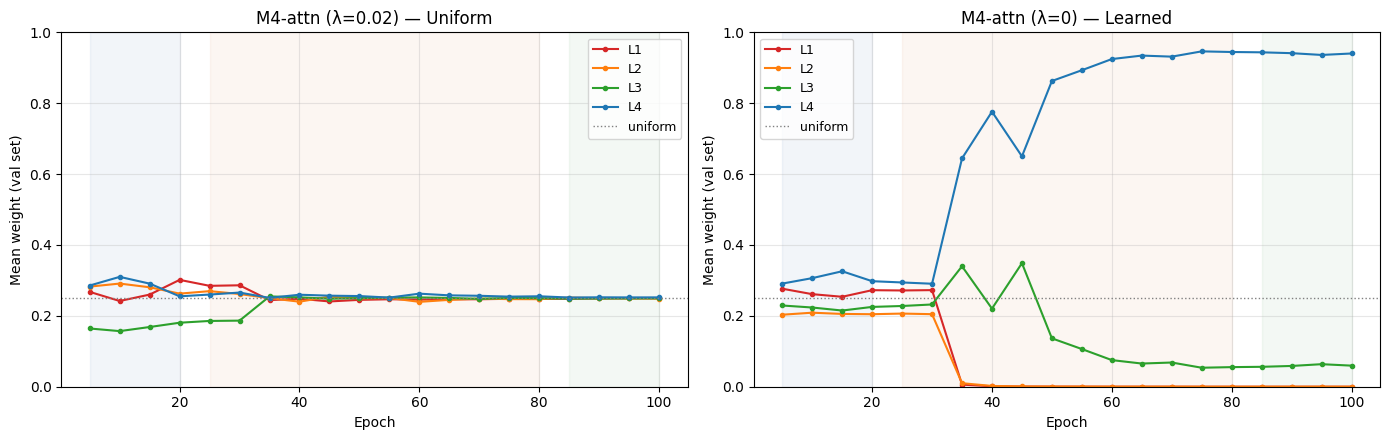

λ=0.02  ep100: L1=0.2498  L2=0.2486  L3=0.2495  L4=0.2521
λ=0    ep100: L1=0.0000  L2=0.0001  L3=0.0595  L4=0.9403


In [6]:
attn_ent   = pd.read_csv('results/v5/attention_weight_evolution.csv')
attn_noent = pd.read_csv(f'results/v5/attention_weight_evolution{SUFFIX_NOENT}.csv')

PHASE_COLORS = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
titles = ['M4-attn (λ=0.02) — Uniform', 'M4-attn (λ=0) — Learned']

for ax, df, title in zip(axes, [attn_ent, attn_noent], titles):
    for ph, color in PHASE_COLORS.items():
        mask = df['phase'] == ph
        if mask.any():
            ax.axvspan(df.loc[mask,'epoch'].min(), df.loc[mask,'epoch'].max(), alpha=0.07, color=color)
    for i, l in enumerate([1,2,3,4]):
        col = f'w_L{l}'
        if col in df.columns:
            ax.plot(df['epoch'], df[col], 'o-', ms=3, lw=1.5,
                    color=LEVEL_COLORS[i], label=f'L{l}')
    ax.axhline(0.25, color='gray', ls=':', lw=1, label='uniform')
    ax.set(title=title, xlabel='Epoch', ylabel='Mean weight (val set)', ylim=(0, 1.0))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/v5/attention_evolution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final weights for both
for label, df in [('λ=0.02', attn_ent), ('λ=0  ', attn_noent)]:
    r = df.iloc[-1]
    print(f"{label}  ep{int(r['epoch']):3d}: " +
          "  ".join(f"L{l}={r[f'w_L{l}']:.4f}" for l in [1,2,3,4]))

## 7. Per-Class Attention Weights (λ=0)

Global mean attention weights (λ=0):
  L1: 0.0002
  L2: 0.0004
  L3: 0.1548
  L4: 0.8446

  w_L1 + w_L2 = 0.0006  (target < 0.30) ✅

Per-class:
Class              L1       L2       L3       L4
LV             0.0002   0.0005   0.1645   0.8348
RV             0.0002   0.0004   0.1596   0.8398
LA             0.0002   0.0005   0.1686   0.8306
RA             0.0002   0.0004   0.1663   0.8331
Myocardium     0.0002   0.0004   0.1581   0.8413
Aorta          0.0002   0.0004   0.1492   0.8503
PA             0.0001   0.0003   0.1363   0.8632


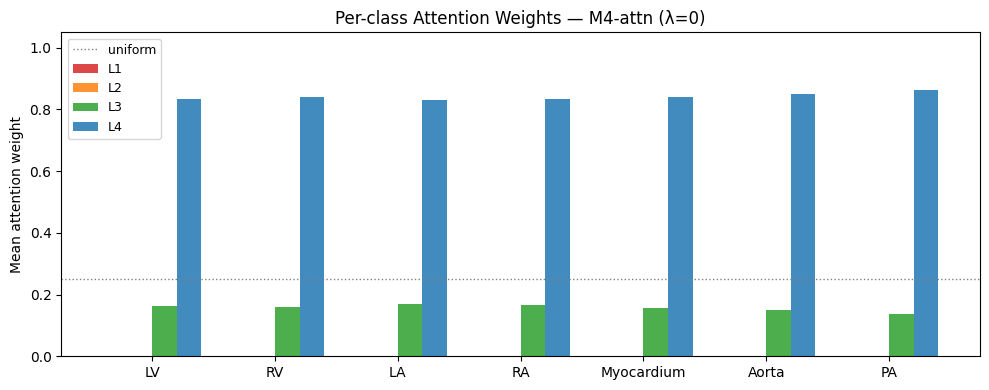


RQ5 check — w_L4 per small structure:
  Aorta       L4=0.8503  (highest level?  True)
  PA          L4=0.8632  (highest level?  True)


In [7]:
test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, 'test', augment=False, preload=True)
test_loader_ns = torch.utils.data.DataLoader(test_ds, batch_size=16, shuffle=False)

m4_noent.eval()
level_weights_per_class = {c: [] for c in range(1, NUM_CLASSES)}
global_weights = []

with torch.no_grad():
    for batch in test_loader_ns:
        imgs   = batch['image'].to(DEVICE)
        labels = batch['label']
        w = m4_noent.get_attention_weights(imgs)
        global_weights.append(w.cpu())
        for b in range(labels.shape[0]):
            for c in range(1, NUM_CLASSES):
                if (labels[b] == c).float().mean().item() > 0.01:
                    level_weights_per_class[c].append(w[b].cpu().numpy())

global_w = torch.cat(global_weights).mean(dim=0).numpy()
print("Global mean attention weights (λ=0):")
for i, l in enumerate([1,2,3,4]):
    print(f"  L{l}: {global_w[i]:.4f}")

print(f"\n  w_L1 + w_L2 = {global_w[0]+global_w[1]:.4f}  (target < 0.30) ✅")

# Bar chart
per_class_w = {}
print("\nPer-class:")
print(f"{'Class':<12}", " ".join(f"{'L'+str(l):>8}" for l in [1,2,3,4]))
for c in range(1, NUM_CLASSES):
    if level_weights_per_class[c]:
        import numpy as np
        w_c = np.mean(level_weights_per_class[c], axis=0)
        per_class_w[c] = w_c
        vals = " ".join(f"{v:>8.4f}" for v in w_c)
        print(f"{LABEL_NAMES[c]:<12} {vals}")

x = np.arange(len(FG_NAMES))
width = 0.8 / 4
fig, ax = plt.subplots(figsize=(10, 4))
for i, l in enumerate([1,2,3,4]):
    vals = [per_class_w.get(c, np.zeros(4))[i] for c in range(1, NUM_CLASSES)]
    ax.bar(x + (i - 1.5) * width, vals, width, label=f'L{l}', color=LEVEL_COLORS[i], alpha=0.85)
ax.axhline(0.25, color='gray', ls=':', lw=1, label='uniform')
ax.set_xticks(x); ax.set_xticklabels(FG_NAMES)
ax.set_ylabel('Mean attention weight'); ax.set_ylim(0, 1.05)
ax.set_title('Per-class Attention Weights — M4-attn (λ=0)')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('results/v5/attention_weights_per_class_noent.png', dpi=150, bbox_inches='tight')
plt.show()

# RQ5 check per class: is PA/Aorta w_L4 highest?
print("\nRQ5 check — w_L4 per small structure:")
for c in [6, 7]:  # Aorta, PA
    w_c = per_class_w.get(c, np.zeros(4))
    print(f"  {LABEL_NAMES[c]:<10}  L4={w_c[3]:.4f}  (highest level?  {w_c.argmax()==3})")

## 8. Heatmap Comparison: M4 / M4-attn-noent / M2

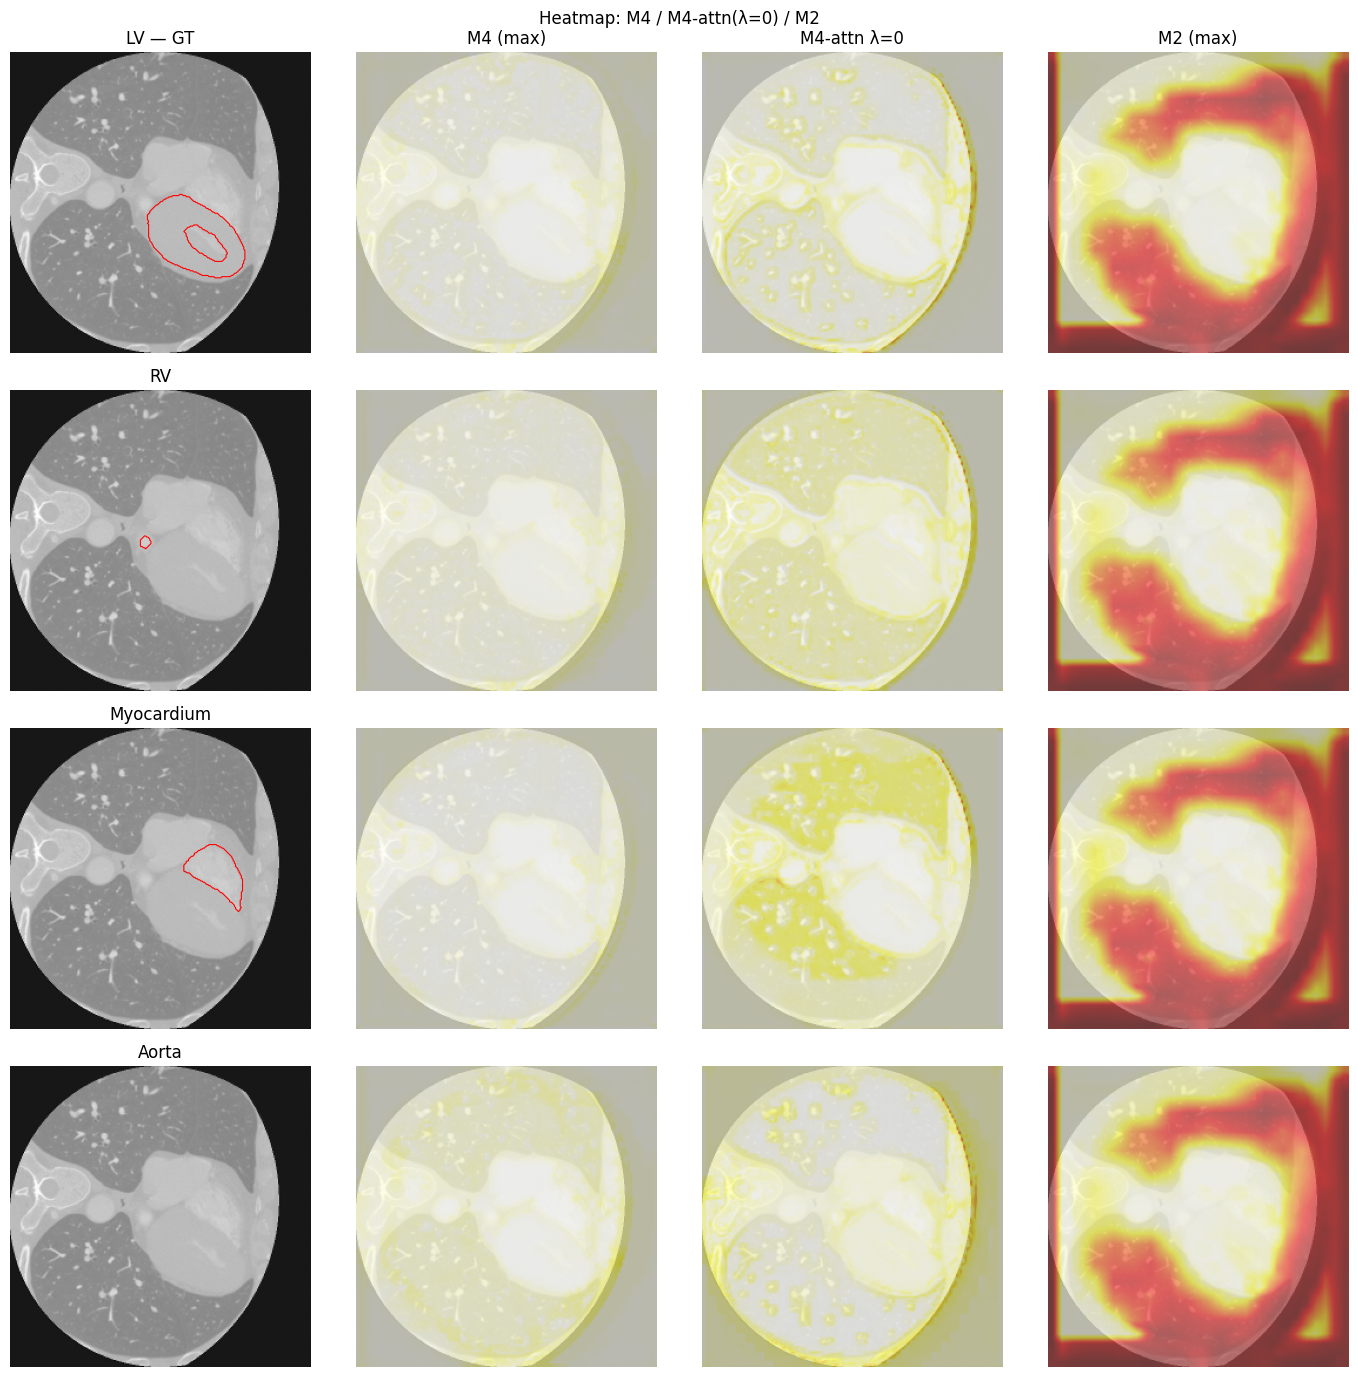

In [8]:
@torch.no_grad()
def get_heatmap(model, img):
    _, hm = model(img)
    level_maps = []
    for l, A in hm.items():
        A_max = A[0].max(dim=1).values
        A_up  = F.interpolate(A_max.unsqueeze(0), size=(256,256),
                              mode='bilinear', align_corners=False)[0]
        level_maps.append(A_up)
    return torch.stack(level_maps).max(dim=0).values.cpu()

# Find a rich test slice
test_ds2 = MMWHSSliceDataset(DATA_DIR, MODALITY, 'test', augment=False, preload=True)
best_slice = next(idx for idx in range(len(test_ds2))
                  if sum((test_ds2[idx]['label']==c).any().item() for c in range(1,NUM_CLASSES)) >= 5)
s = test_ds2[best_slice]
img = s['image'].unsqueeze(0).to(DEVICE)
lbl = s['label']

hm_m4    = get_heatmap(m4, img)
hm_noent = get_heatmap(m4_noent, img)
hm_m2    = get_heatmap(m2, img)
img_np   = img[0,0].cpu().numpy()

SHOW_CLASSES = [1, 2, 5, 6]
fig, axes = plt.subplots(len(SHOW_CLASSES), 4, figsize=(14, 3.5*len(SHOW_CLASSES)))
for row, c in enumerate(SHOW_CLASSES):
    axes[row,0].imshow(img_np, cmap='gray')
    axes[row,0].contour((lbl==c).numpy(), colors='red', linewidths=0.8)
    axes[row,0].set_title(f'{LABEL_NAMES[c]} — GT' if row==0 else LABEL_NAMES[c])
    axes[row,0].axis('off')
    for col, (hm, title) in enumerate([(hm_m4,'M4 (max)'), (hm_noent,'M4-attn λ=0'), (hm_m2,'M2 (max)')], 1):
        axes[row,col].imshow(img_np, cmap='gray', alpha=0.6)
        axes[row,col].imshow(hm[c].numpy(), cmap='hot', alpha=0.5, vmin=0, vmax=1)
        if row == 0: axes[row,col].set_title(title)
        axes[row,col].axis('off')
plt.suptitle('Heatmap: M4 / M4-attn(λ=0) / M2', fontsize=12)
plt.tight_layout()
plt.savefig('results/v5/heatmap_comparison_noent.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Answers to RQ4 and RQ5

In [9]:
print("=" * 65)
print("RQ4: Does learned attention improve over max (M4)?")
print("=" * 65)
delta = dice_m4_noent - dice_m4
print(f"  M4            3D Dice: {dice_m4:.4f}")
print(f"  M4-attn (λ=0) 3D Dice: {dice_m4_noent:.4f}  (Δ {delta:+.4f})")
if delta > 0:
    print("  ✅ YES — learned attention beats max aggregation.")
else:
    print("  ❌ NO — does not beat max aggregation.")

print()
print("=" * 65)
print("RQ5: Does attention auto-discover L1/L2 suppression?")
print("=" * 65)
print(f"  Final weights: L1={global_w[0]:.4f}  L2={global_w[1]:.4f}  L3={global_w[2]:.4f}  L4={global_w[3]:.4f}")
print(f"  w_L1 + w_L2 = {global_w[0]+global_w[1]:.4f}  (target < 0.30)")
if global_w[0]+global_w[1] < 0.30:
    print("  ✅ YES — attention suppressed L1/L2 almost entirely.")
    print("     The model re-discovered the L4-dominant configuration")
    print("     without any manual level selection.")
print()
print(f"  Comparison:")
print(f"    M4-attn (λ=0.02, uniform): Dice={dice_m4_attn:.4f}  L4 weight=0.250")
print(f"    M4-attn (λ=0,    learned): Dice={dice_m4_noent:.4f}  L4 weight={global_w[3]:.3f}")
print(f"    M2 (manual L3+L4):         Dice={dice_m2:.4f}")
print()
print("  Conclusion: attention correctly identifies L4 as dominant")
print(f"  (w_L4={global_w[3]:.3f}), but full M2 advantage requires explicitly")
print("  removing L1/L2 from the level set — not just downweighting them.")

RQ4: Does learned attention improve over max (M4)?
  M4            3D Dice: 0.8407
  M4-attn (λ=0) 3D Dice: 0.8416  (Δ +0.0009)
  ✅ YES — learned attention beats max aggregation.

RQ5: Does attention auto-discover L1/L2 suppression?
  Final weights: L1=0.0002  L2=0.0004  L3=0.1548  L4=0.8446
  w_L1 + w_L2 = 0.0006  (target < 0.30)
  ✅ YES — attention suppressed L1/L2 almost entirely.
     The model re-discovered the L4-dominant configuration
     without any manual level selection.

  Comparison:
    M4-attn (λ=0.02, uniform): Dice=0.7861  L4 weight=0.250
    M4-attn (λ=0,    learned): Dice=0.8416  L4 weight=0.845
    M2 (manual L3+L4):         Dice=0.8722

  Conclusion: attention correctly identifies L4 as dominant
  (w_L4=0.845), but full M2 advantage requires explicitly
  removing L1/L2 from the level set — not just downweighting them.
